# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# mostrar las primeras 5 filas de plans
plans.head(5)

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head(5)

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?
    - Users: city y churn_date.
    - Usage: date, duration y length  
- Indica qué harías: ¿imputar, eliminar, ignorar?
    - city: Investigar e imputar o dejar como nulos.
    - churn_date: ignorar o eliminar.
    - date: Imputar o eliminar registros.
    - duration: Investigar antes de imputar, debido al alto porcentaje de valores faltantes.
    - length: Investigar antes de imputar, debido al alto porcentaje de valores faltantes.

**Para Users:** La columna city presenta un 11.73% de valores faltantes, por lo que se recomienda evaluar una estrategia de imputación o dejar como nulos. La columna churn_date tiene 88.35% de nulos, por lo que no se recomienda eliminarla.

**Para Usage:** La columna date presenta pocos valores faltantes y puede imputarse o dejarse como nulo. Las columnas duration y length tienen porcentajes elevados de nulos (55.19% y 44.74%), por lo que es necesario investigar si los valores faltantes tienen una causa operativa o si están relacionados con ciertos tipos de registros antes de decidir entre imputar o eliminar.

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id` contiene identificadores de usuario que van de 10000 a 13999. No se observan valores inválidos ni sentinels, ya que los datos siguen una secuencia consistente y están dentro del rango esperado para un identificador.
- La columna `age` presenta un valor mínimo de -999, el cual es imposible para una edad y probablemente corresponde a un valor sentinel utilizado para representar datos faltantes o desconocidos. El resto de los valores se encuentran entre 32 y 79 años.

In [13]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id`contiene identificadores únicos de registros con valores entre 1 y 40000. No se observan valores inválidos ni sentinels, ya que los datos siguen una secuencia lógica y consistente.
- La columna `duration` presenta valores entre 0 y 120. No se observan valores negativos ni sentinels evidentes. Sin embargo, existen registros con duración igual a 0 que podrían representar eventos sin duración o registros incompletos, por lo que conviene validar su significado.
- La columna `length` presenta valores entre 0 y 1490. No se identifican valores negativos ni sentinels evidentes. Los valores de 0 deben revisarse para confirmar si representan registros válidos o posibles datos faltantes.

In [14]:
# explorar columnas categóricas de users
columnas_user = ['city', 'plan']
users[columnas_user].value_counts(normalize=True)

city      plan   
Bogotá    Basico     0.147833
CDMX      Basico     0.134240
Medellín  Basico     0.112716
GDL       Basico     0.084395
Bogotá    Premium    0.080997
MTY       Basico     0.077882
Cali      Basico     0.074200
CDMX      Premium    0.072501
Medellín  Premium    0.061739
Cali      Premium    0.045879
GDL       Premium    0.043047
MTY       Premium    0.037383
?         Basico     0.018408
          Premium    0.008779
dtype: float64

- La columna `city` se observa la categoría "?", la cual probablemente representa un valor desconocido o mal capturado y puede considerarse un valor inválido/sentinel.
- La columna `plan` únicamente contiene las categorías "Basico" y "Premium". No se observan valores inválidos, sentinels ni categorías inesperadas.

In [15]:
# explorar columna categórica de usage
usage['type'].value_counts(normalize=True)

text    0.5523
call    0.4477
Name: type, dtype: float64

- La columna `type` contiene únicamente las categorías "text" (55.23%) y "call" (44.77%). No se detectan valores inválidos ni sentinels, y la distribución parece razonable.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
    - `age`: valor sentinel -999.
    - `city`: categoría inválida "?".
- ¿Qué acción tomarías?
    - Reemplazar -999 y ? por NaN, promedio o media dependiendo del caso.
    - Analizar posteriormente si conviene imputar o eliminar los registros afectados.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors="coerce")

In [17]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors="coerce")

In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts()

2024    1330
2023    1316
2022    1314
2026      40
Name: reg_date, dtype: int64

En `reg_date`, se observan registros correspondientes a los años 2022, 2023 y 2024, que son años válidos dentro del período esperado. Sin embargo, aparecen 40 registros del año 2026, lo cual representa fechas futuras respecto al límite establecido (2024), por lo que pueden considerarse fechas fuera de rango o errores de captura.

In [19]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts()

2024.0    39950
Name: date, dtype: int64

En `date`, todos los registros pertenecen al año 2024, por lo que no se identifican fechas fuera de rango ni años imposibles. La distribución es consistente con el período de análisis.  
Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)
    - Sí. En la columna reg_date aparecen 40 registros del año 2026, que corresponden a fechas futuras considerando que el dataset sólo contiene información hasta 2024.
- ¿Qué harías con ellas?
    - Investigar si se trata de errores de captura o de formato.
    - Si son errores evidentes, corregirlos si existe información para hacerlo.
    - En caso de no poder validarlos, reemplazarlos por NaN o excluir esos registros del análisis para evitar sesgos.
    - Mantener sin cambios la columna date, ya que no presenta fechas fuera de rango.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
numeric_sentinels = [-999]
users['age'] = users['age'].replace(numeric_sentinels, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
text_sentinels = ["?"]
users["city"] = users["city"].replace(text_sentinels, "NA")

# Verificar cambios
users['city'].describe()

count       3531
unique         7
top       Bogotá
freq         808
Name: city, dtype: object

In [22]:
# Marcar fechas futuras como NA para reg_date
users.loc[users["reg_date"].dt.year > 2024, "reg_date"] = pd.NaT

# Verificar cambios
users["reg_date"].dt.year.value_counts(dropna=False)

2024.0    1330
2023.0    1316
2022.0    1314
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
usage['duration'].isna().groupby(usage['type']).sum()


type
call        0
text    22076
Name: duration, dtype: int64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage['length'].isna().groupby(usage['type']).sum()


type
call    17896
text        0
Name: length, dtype: int64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

Los nulos en `duration` y `length` dependen totalmente de la columna `type`. Los mensajes de texto no tienen duración y las llamadas no tienen longitud de mensaje. Por ello, los nulos son esperados y se mantendrán sin imputación.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = usage.groupby("user_id")[["is_text","is_call","duration"]].sum().reset_index()

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text":"cant_mensajes",
    "is_call":"cant_llamadas",
    "duration":"cant_minutos_llamada"
})
# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
user_profile.value_counts(normalize=True)

user_id  first_name  last_name  age   city      reg_date                       plan     churn_date   cant_mensajes  cant_llamadas  cant_minutos_llamada
10032    Carlos      Lopez      44.0  MTY       2022-01-09 18:17:33.263315829  Premium  1,71832E+18  8.0            2.0            19.12                   0.00241
12615    Mariana     Lopez      41.0  Bogotá    2023-12-18 00:50:46.361590400  Basico   1,72705E+18  4.0            7.0            52.55                   0.00241
12748    Luis        Torres     74.0  CDMX      2024-01-23 10:52:28.987246816  Premium  1,73474E+18  7.0            4.0            36.37                   0.00241
12722    Mateo       Gomez      77.0  MTY       2024-01-16 08:00:43.210802704  Basico   1,72757E+18  7.0            2.0            8.48                    0.00241
12715    Carlos      Torres     44.0  NA        2024-01-14 10:00:37.809452368  Basico   1,73085E+18  5.0            3.0            8.57                    0.00241
                                 

In [29]:
# Distribución porcentual del tipo de plan
user_profile[['plan']].value_counts(normalize=True)

plan   
Basico     0.64875
Premium    0.35125
dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

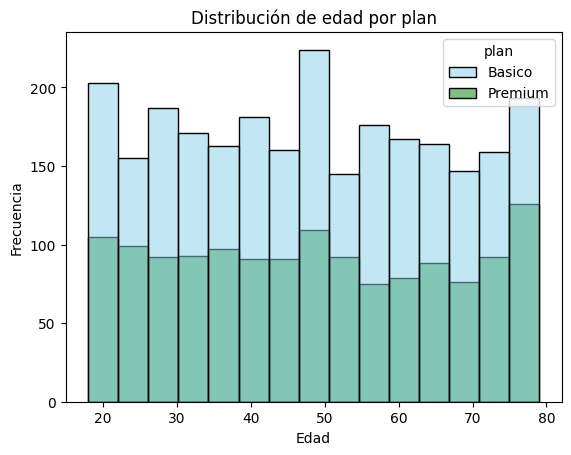

In [30]:
# Histograma para visualizar la edad (age)
sns.histplot( data=user_profile,
    x="age",
    hue="plan",
    bins=15,
    palette=["skyblue", "green"])
plt.title("Distribución de edad por plan")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()
plt.show()

💡Insights: 
- La distribución de edades es bastante uniforme entre los planes Básico y Premium, sin concentraciones marcadas en algún grupo etario específico. No se observa una relación clara entre la edad del usuario y el tipo de plan contratado. La distribución es aproximadamente simétrica y no presenta sesgos importantes.

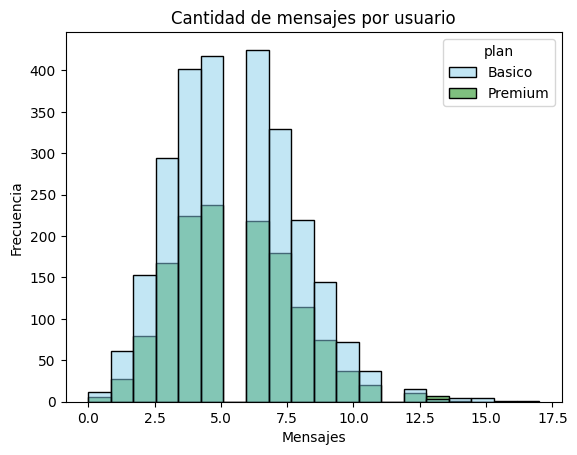

In [31]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x="cant_mensajes",
    hue="plan",
    bins=20,
    palette=["skyblue", "green"]
)

plt.title("Cantidad de mensajes por usuario")
plt.xlabel("Mensajes")
plt.ylabel("Frecuencia")
plt.show()

💡Insights: 
- La mayoría de los usuarios envía entre 3 y 8 mensajes durante el período analizado. Los usuarios de los planes Básico y Premium presentan patrones de uso muy similares, aunque existe un pequeño grupo de usuarios con una cantidad de mensajes considerablemente mayor. La distribución presenta un ligero sesgo hacia la derecha debido a estos usuarios de alto uso.

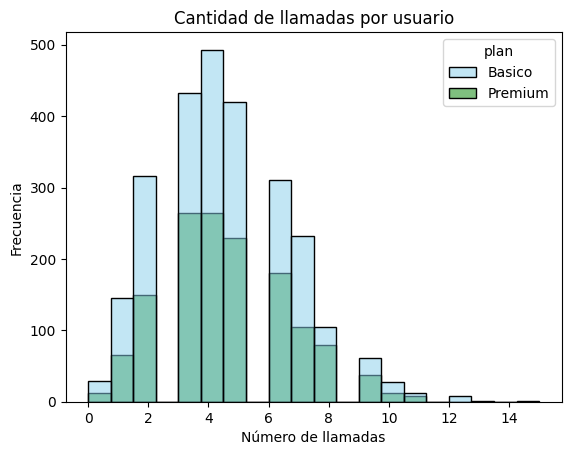

In [32]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x="cant_llamadas",
    hue="plan",
    bins=20,
    palette=["skyblue", "green"]
)

plt.title("Cantidad de llamadas por usuario")
plt.xlabel("Número de llamadas")
plt.ylabel("Frecuencia")
plt.show()

💡Insights: 
- La mayor parte de los usuarios realiza entre 2 y 7 llamadas. No se observan diferencias relevantes entre los planes Básico y Premium en cuanto al número de llamadas realizadas. La distribución muestra una ligera asimetría positiva, con pocos usuarios realizando muchas llamadas.

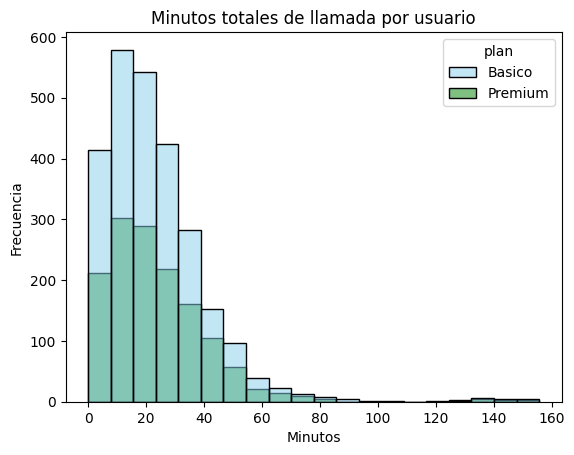

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x="cant_minutos_llamada",
    hue="plan",
    bins=20,
    palette=["skyblue", "green"]
)

plt.title("Minutos totales de llamada por usuario")
plt.xlabel("Minutos")
plt.ylabel("Frecuencia")
plt.show()

💡Insights: 
- La mayoría de los usuarios acumula menos de 40 minutos de llamada. Sin embargo, existe un pequeño grupo de usuarios con consumos significativamente mayores, alcanzando más de 100 minutos. Esta variable presenta una clara distribución sesgada a la derecha, característica de métricas de consumo donde pocos usuarios concentran gran parte del uso.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

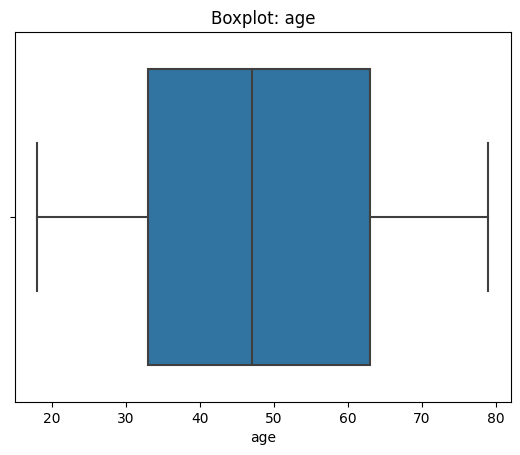

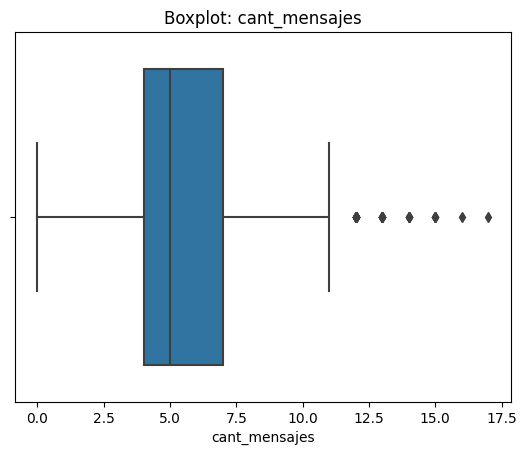

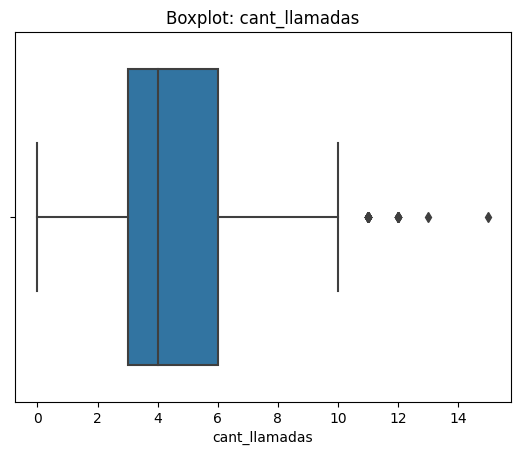

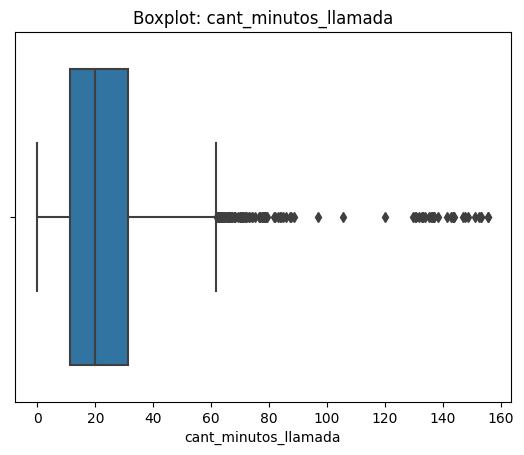

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data=user_profile, x=col)
    plt.title(f'Boxplot: {col}')
    plt.show()

💡Insights: 
- Age: La variable edad no presenta valores atípicos. La distribución es relativamente simétrica, con una mediana cercana a los 47 años y una dispersión uniforme entre aproximadamente 18 y 79 años.
- cant_mensajes: La mayoría de los usuarios envía entre 4 y 7 mensajes. Se observan algunos usuarios con cantidades significativamente mayores (12 a 17 mensajes), considerados valores atípicos altos. La distribución presenta un ligero sesgo hacia la derecha.
- cant_llamadas: La mayoría de los usuarios realiza entre 3 y 6 llamadas. Se observan pocos usuarios con más de 10 llamadas, los cuales aparecen como valores atípicos. La distribución muestra una ligera asimetría positiva.
- cant_minutos_llamada: La variable presenta una fuerte asimetría positiva. La mayoría de los usuarios acumula menos de 40 minutos, pero existe un grupo reducido con consumos muy elevados (más de 60 minutos e incluso superiores a 150 minutos), generando numerosos valores atípicos.

In [35]:
# Calcular límites con el método IQR
columnas_limites = ["cant_mensajes","cant_llamadas","cant_minutos_llamada"]

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_superior = Q3 + 1.5 * IQR
    print(col,"limite:",limite_superior)

cant_mensajes limite: 11.5
cant_llamadas limite: 10.5
cant_minutos_llamada limite: 61.8575


In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- cant_mensajes: se identifican valores atípicos por encima de 11.5 mensajes. Sin embargo, el valor máximo observado (17 mensajes) no parece extremo ni imposible dentro del contexto del uso de una plataforma de comunicaciones. Se recomienda mantener los outliers, ya que probablemente representan usuarios con una actividad de mensajería superior al promedio y no errores en los datos.
- cant_llamadas: existen valores atípicos por encima de 10.5 llamadas. No obstante, el máximo registrado de 15 llamadas sigue siendo razonable y puede corresponder a usuarios con un uso intensivo del servicio. Se recomienda mantener los outliers, ya que aportan información relevante sobre distintos patrones de comportamiento.
- cant_minutos_llamada: presenta una mayor cantidad de valores atípicos y una clara asimetría positiva. Aunque algunos usuarios superan ampliamente el límite superior de 61.86 minutos, el máximo registrado (155.69 minutos) sigue siendo plausible para usuarios con un uso elevado de llamadas. Se recomienda mantener los outliers, ya que reflejan diferencias reales en el consumo y no evidencian errores de captura.

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [37]:

# Crear columna grupo_uso
def classify_grupo(row):
    cant_llamadas = row["cant_llamadas"]
    cant_mensajes = row["cant_mensajes"]

    if pd.isna(cant_llamadas) or pd.isna(cant_mensajes):
        return "Error en Datos"

    if (cant_llamadas < 5) & (cant_mensajes < 5):
        return "Bajo uso"
    elif (cant_llamadas < 10) & (cant_mensajes < 10):
        return "Uso medio"
    else:
        return "Alto uso"

# aplicar función
user_profile["grupo_uso"] = user_profile.apply(classify_grupo, axis=1)



In [38]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [42]:
# Crear columna grupo_edad
def classify_edad(row):
    edad = row["age"]

    if pd.isna(edad):
        return "Error en Datos"

    if (edad < 30):
        return "Joven"
    elif (edad < 60):
        return "Adulto"
    else:
        return "Adulto mayor"

# aplicar función
user_profile["grupo_edad"] = user_profile.apply(classify_edad, axis=1)


In [43]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NA,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

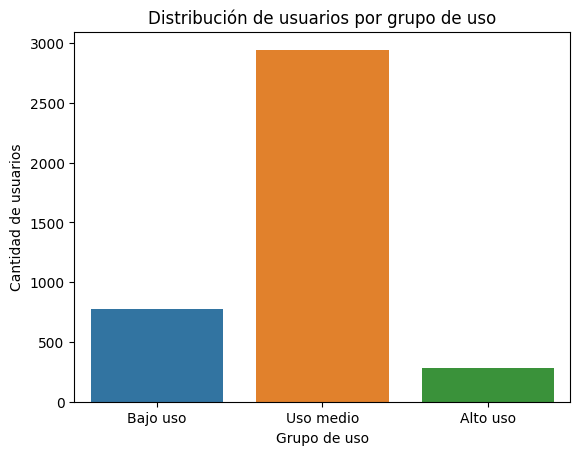

In [44]:
# Visualización de los segmentos por uso
sns.countplot(data=user_profile,
    x="grupo_uso",
    order=["Bajo uso", "Uso medio", "Alto uso"]
)
plt.title("Distribución de usuarios por grupo de uso")
plt.xlabel("Grupo de uso")
plt.ylabel("Cantidad de usuarios")
plt.show()

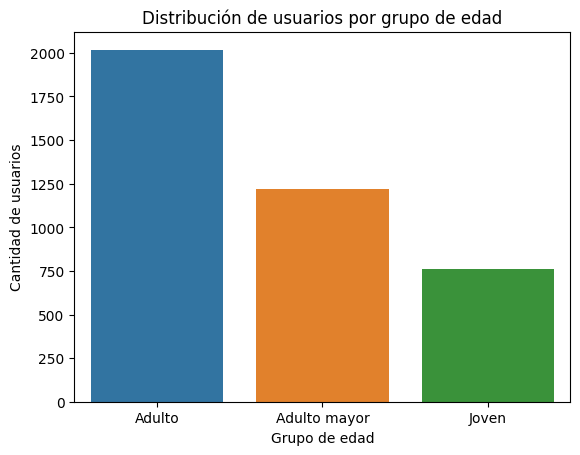

In [45]:
# Visualización de los segmentos por edad
sns.countplot(
    data=user_profile,
    x="grupo_edad"
)

plt.title("Distribución de usuarios por grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Cantidad de usuarios")

plt.show()


---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- La columna city presentaba 469 valores faltantes (11.73%) y registros con el valor sentinel "?", los cuales fueron tratados como valores nulos.
- La columna churn_date contenía 3,534 valores nulos (88.35%), lo cual se consideró esperado porque representa usuarios que no han cancelado el servicio.
- En age se detectó el valor inválido -999, utilizado como sentinel para indicar datos faltantes.
- En reg_date se encontraron 40 registros con fechas futuras (año 2026), las cuales fueron marcadas como valores faltantes por estar fuera del rango esperado.
- Las columnas duration y length presentaban altos porcentajes de nulos, pero se comprobó que dependían directamente del tipo de registro (call o text), por lo que se mantuvieron al representar información válida.


🔍 **Segmentos por Edad**
- La distribución de edades mostró una población bastante homogénea entre los planes Básico y Premium, sin diferencias significativas por rango de edad. Esto sugiere que la edad no es un factor determinante para la contratación de un plan específico.

📊 **Segmentos por Nivel de Uso**
- El análisis permitió clasificar a los usuarios en segmentos de Bajo uso, Uso medio y Alto uso, considerando la cantidad de llamadas y mensajes realizados.
- Los usuarios de Alto uso representan el segmento con mayor valor potencial para ConnectaTel, ya que generan una mayor utilización de los servicios de llamadas y mensajería. Estos clientes son candidatos ideales para planes con mayores beneficios, paquetes ilimitados o programas de fidelización.
- Los usuarios de Uso medio constituyen la mayor base de clientes y representan una oportunidad importante para estrategias de upselling hacia planes con mayores beneficios.


➡️ Esto sugiere que el nivel de consumo es un mejor criterio de segmentación que la edad o el tipo de plan, ya que permite identificar usuarios con comportamientos significativamente diferentes y oportunidades de negocio más claras
- Se identificaron valores atípicos en:
    - Cantidad de mensajes.
    - Cantidad de llamadas.
    - Minutos totales de llamada.
- Sin embargo, los máximos observados (17 mensajes, 15 llamadas y 155.69 minutos) son consistentes con usuarios de alto consumo y no parecen errores de captura. Por ello, se decidió conservarlos, ya que reflejan comportamientos reales y permiten identificar segmentos de alto valor.
- Los valores atípicos fueron conservados debido a que representan usuarios reales con patrones de consumo elevados y no errores de captura, por lo que aportan información valiosa para la segmentación de clientes.
- El análisis muestra que la mayoría de los clientes presenta un uso moderado de los servicios, mientras que un grupo reducido concentra niveles de consumo significativamente mayores. La segmentación realizada permite identificar oportunidades de personalización de planes, estrategias de fidelización y acciones comerciales enfocadas en maximizar el valor de cada segmento de clientes.

💡 **Recomendaciones**
- Diseñar planes específicos para usuarios de alto consumo, ofreciendo mayores beneficios en llamadas y mensajería.
- Implementar campañas de migración para usuarios de uso medio que puedan beneficiarse de planes Premium.
- Mantener monitoreo continuo de usuarios con patrones de consumo elevados para identificar oportunidades de fidelización.
- Mejorar los procesos de captura y validación de datos para evitar sentinels, fechas fuera de rango y valores inválidos en futuros análisis.
- Evaluar la posibilidad de crear planes diferenciados según nivel de uso, en lugar de segmentarlos únicamente por tipo de plan (Básico o Premium).

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`